In [195]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [250]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

In [197]:
HwannierUp, cellmapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt")
HwannierDn, cellmapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");
lattice_vectors = loadlattice("wannier.out");

In [198]:
kpoints = bandstructkpoints2q(kpointsfile="../bandstruct.kpoints", interpolate=5);

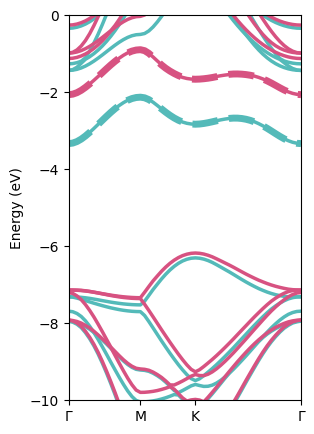

PyObject Text(0.5, 4.444444444444445, '')

In [4]:
color_up = "#54BAB9"
color_dn = "#D75281"
figure(figsize=(3, 5))
plot_bands("../BN22BC.bands.eigenvals", kpointsfile="../bandstruct.kpoints", spin=2, linewidth=2.5, color_dn = color_dn,  
    color_up=color_up)
ylim(-4, -2)
plot_bands(HwannierUp, cellmapUp, kpointsfile="../bandstruct.kpoints", color=color_up, linestyle="dashed", linewidth=5)
plot_bands(HwannierDn, cellmapDn, kpointsfile="../bandstruct.kpoints", color=color_dn, linestyle="dashed", linewidth=5)

label_plots("../bandstruct.kpoints.in", "../bandstruct.kpoints")
ylim(-10, 0)
xlabel("")

In [59]:
es, ds = density_of_states(HwannierUp, cellmapUp, Val(2), monte_carlo=true, mesh=30, num_blocks=1000, histogram_width=100)

([-4.333444997298599, -4.32345670880393, -4.3134684203092615, -4.3034801318145925, -4.293491843319924, -4.283503554825255, -4.273515266330586, -4.263526977835917, -4.253538689341248, -4.243550400846579  …  -1.227087275456575, -1.217098986961906, -1.207110698467237, -1.1971224099725681, -1.1871341214778992, -1.1771458329832303, -1.1671575444885613, -1.1571692559938929, -1.147180967499224, -1.137192679004555], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

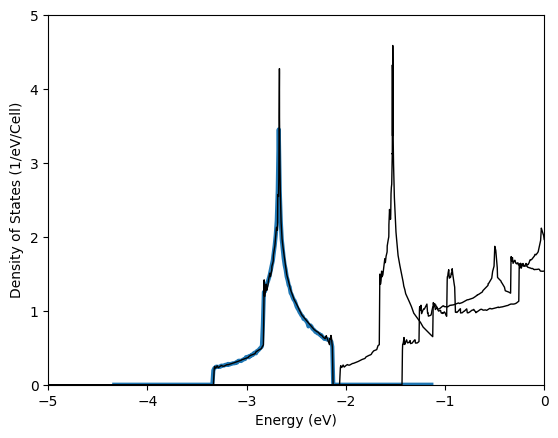

(-5.0, 0.0)

In [66]:
plot(es, ds, linewidth=3)
density_of_states("../DOS/BN22BC.dosUp", color="black")
density_of_states("../DOS/BN22BC.dosDn", color="black")

ylim(0, 5)
xlim(-5, 0)

In [72]:
es, cs = find_chemical_potential(es, ds)

es[argmin(abs.(cs .- 1))]

-2.046126932019424

In [141]:
polarizations = []
for (i,k) in enumerate(kpoints[1:100])
    println(i); flush(stdout)
    push!(polarizations, ImΠ(HwannierUp, cellmapUp, lattice_vectors, k, -2.64, Val(2), histogram_width=1000, mesh=100, monte_carlo=true))
end

1
[0.0, 0.0, 0.0]
2
[0.0058823529412, 0.0, 0.0]
3
[0.0117647058824, 0.0, 0.0]
4
[0.0176470588236, 0.0, 0.0]
5
[0.0235294117648, 0.0, 0.0]
6
[0.029411764706, 0.0, 0.0]
7
[0.0352941176472, 0.0, 0.0]
8
[0.0411764705884, 0.0, 0.0]
9
[0.0470588235296, 0.0, 0.0]
10
[0.0529411764708, 0.0, 0.0]
11
[0.058823529412, 0.0, 0.0]
12
[0.0647058823532, 0.0, 0.0]
13
[0.0705882352944, 0.0, 0.0]
14
[0.0764705882356, 0.0, 0.0]
15
[0.0823529411768, 0.0, 0.0]
16
[0.088235294118, 0.0, 0.0]
17
[0.0941176470592, 0.0, 0.0]
18
[0.1000000000004, 0.0, 0.0]
19
[0.1058823529416, 0.0, 0.0]
20
[0.1117647058828, 0.0, 0.0]
21
[0.117647058824, 0.0, 0.0]
22
[0.123529411765, 0.0, 0.0]
23
[0.129411764706, 0.0, 0.0]
24
[0.135294117647, 0.0, 0.0]
25
[0.14117647058799998, 0.0, 0.0]
26
[0.147058823529, 0.0, 0.0]
27
[0.1529411764702, 0.0, 0.0]
28
[0.1588235294114, 0.0, 0.0]
29
[0.1647058823526, 0.0, 0.0]
30
[0.1705882352938, 0.0, 0.0]
31
[0.176470588235, 0.0, 0.0]
32
[0.1823529411762, 0.0, 0.0]
33
[0.1882352941174, 0.0, 0.0]
34


In [440]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_scipy = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    for (j, ω) in enumerate(range(0.05, 2, length=100))
       epsilons_scipy[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=100), Val(2), Val(:scipy), limit=50, δ=0.001, normalized=true))
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [418]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_default = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    for (j, ω) in enumerate(range(0.05, 2, length=100))
        epsilons_default[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=100), Val(2), Val(:default), limit=20, δ=0.001, normalized=true))
    end
end

In [434]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_quadgk = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    for (j, ω) in enumerate(range(0.05, 2, length=100)[1:100])
    x = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=100), Val(2), Val(:quadgk), rtol=1e-7, atol=1e-7, δ=0.1, normalized=true))
     epsilons_quadgk[i, j] = x
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [419]:
plasmon_default = [range(0.05, 2, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_default[2:50, :])))];
plasmon_default = [0, plasmon_default...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_default);
plasmon_default = smooth(plasmon_default, win_len=10);
plasmon_default[1] = 0;

In [441]:
plasmon_scipy = [range(0.05, 2, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_scipy[2:50, :])))];
plasmon_scipy = [0, plasmon_scipy...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_scipy);
plasmon_scipy = smooth(plasmon_scipy, win_len=10);
plasmon_scipy[1] = 0;

In [438]:
plasmon_quadgk = [range(0.05, 2, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_quadgk[2:50, :])))];
plasmon_quadgk = [0, plasmon_quadgk...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_quadgk);
plasmon_quadgk = smooth(plasmon_quadgk, win_len=10);
plasmon_quadgk[1] = 0;

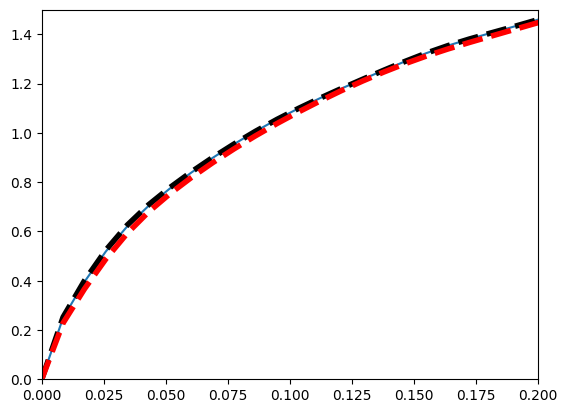

(0.0, 1.5)

In [455]:
plot(qs, plasmon_default)
plot(qs, plasmon_scipy, linestyle="dashed", linewidth=4, color="black")
plot(qs, plasmon_quadgk, linestyle="dashed", linewidth=4, color="red")

xlim(0, 0.2)
ylim(0, 1.5)

In [465]:
np.savetxt("plasmon.txt", hcat(plasmon_default, plasmon_scipy, plasmon_quadgk), header="default, scipy, quadgk")

In [5]:
Heph, celleph_map = hephwannier("wannierUp"), np.loadtxt("wannierUp.mapeph.txt");
Pwannier = pwannier("wannierUp");

In [6]:
force_matrix, cellph_map = phonon_force_matrix("../../BN22BC_Buckled/phonon");
phonon_bands_bn22bc = phonon_dispersion(force_matrix, cellph_map, kpointsfile="../bandstruct.kpoints", return_negative=true);

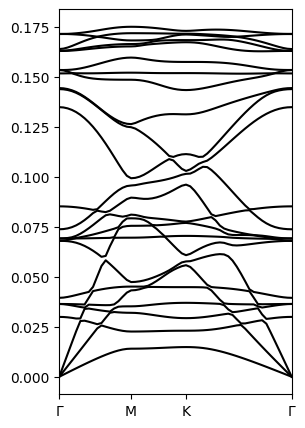

(0.0, 55.0)

In [7]:
figure(figsize=(3, 5))
plot(phonon_bands_bn22bc, color="black")
label_plots("../bandstruct.kpoints.in", "../bandstruct.kpoints")

In [8]:
subsampling = returnfermikpoint(HwannierUp, cellmapUp, -2.65, Val(2), mesh=10, num_blocks=10000, histogram_width=100)

(Real[0.1862254860769188 0.1953336236400569 … 0.2274483585870073 0.020133032839718457; 0.24591829716067437 0.4786715368703838 … 0.6565435159547504 0.731938170351462; 0.0 0.0 … 0.0 0.0], 0.021865)

In [9]:
x, y = density_of_states(HwannierUp, cellmapUp, mesh=20, num_blocks=100, monte_carlo=true)

([-4.333290187042195, -4.3233029804570915, -4.313315773871987, -4.303328567286884, -4.293341360701779, -4.283354154116676, -4.273366947531572, -4.263379740946468, -4.253392534361365, -4.2434053277762604  …  -1.2272689390749076, -1.2172817324898038, -1.2072945259046999, -1.197307319319596, -1.1873201127344921, -1.1773329061493882, -1.1673456995642848, -1.157358492979181, -1.147371286394077, -1.1373840798089732], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

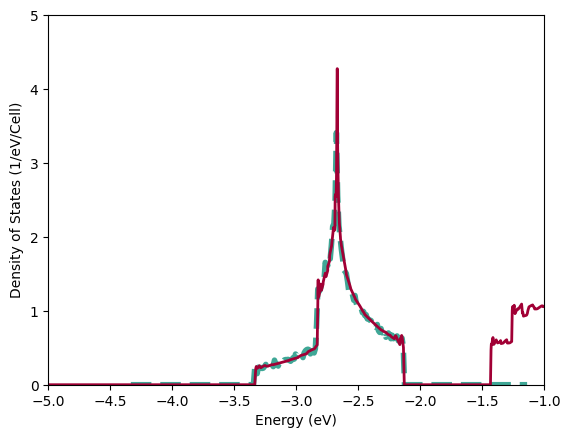

(0.0, 5.0)

In [11]:
# Overlaying the dft vs wannier densities of states
dft_color = "#3FA796"
wannier_color = "#A10035"
plot(x, y, linestyle="dashed", linewidth=4, color=dft_color)
density_of_states("../DOS/BN22BC.dosUp", linewidth=2, color=wannier_color)
xlim(-5, -1)
ylim(0, 5)

In [12]:
gμ  = y[argmin(abs.(x .+ 2.65))]

1.9925000000000002

In [13]:
tau =  τ(HwannierUp, cellmapUp, Pwannier, force_matrix, cellph_map, Heph, celleph_map, collect(0.01:0.01:1), -2.65, Val(:histogram), Val(2); 
mesh=20, supplysampling=subsampling, supplydos=2.023, num_blocks=100, fracroom=1, histogram_width=100)

DOS at Fermi Energy is: 2.023
Sampling from 21865kpoints
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Bl

100-element Vector{Float64}:
 6.319438441408898
 6.259853596260808
 6.163586933466182
 6.0348355425845615
 5.878825463769182
 5.701322086306505
 5.508172972227664
 5.304939590521753
 5.096643513767837
 4.88762490166598
 4.681492924773067
 4.481140500365493
 4.288797019345941
 ⋮
 1.9224829739564366
 1.9197926814675543
 1.9171687894310152
 1.9146088695201178
 1.9121106103903478
 1.9096718107188386
 1.9072903727349695
 1.9049642962021505
 1.9026916728145067
 1.9004706809754568
 1.898299580928178
 1.896176710210585

In [34]:
omegas = 0.01:0.01:1;
np.savetxt("tau.txt", hcat(omegas, tau))

In [34]:
omegas, taus = [col for col in eachcol(np.loadtxt("tau.txt"))]

2-element Vector{SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}:
 [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1  …  0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0]
 [10.538784523088154, 8.854573160430409, 7.479444066180264, 6.354643905720551, 5.432245654823483, 4.673396950142854, 4.046759516191084, 3.5271532263069876, 3.094400751706209, 2.7323583923348522  …  0.4038810642952105, 0.40274986666128737, 0.4016464465564921, 0.400569793238507, 0.39951894441462776, 0.39849298337311834, 0.3974910363159991, 0.39651226987695976, 0.39555588880957165, 0.39462113383233266]

In [15]:
tau_allen =  JJDFTX.τ_allen(HwannierUp, cellmapUp, Pwannier, force_matrix, cellph_map, Heph, celleph_map, collect(0.01:0.01:1), -2.65, Val(2); 
mesh=3, supplydos=2.023, num_blocks=1000, fracroom=1, histogram_width=10)

DOS at Fermi Energy is: 2.023
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98

Block: 753
Block: 754
Block: 755
Block: 756
Block: 757
Block: 758
Block: 759
Block: 760
Block: 761
Block: 762
Block: 763
Block: 764
Block: 765
Block: 766
Block: 767
Block: 768
Block: 769
Block: 770
Block: 771
Block: 772
Block: 773
Block: 774
Block: 775
Block: 776
Block: 777
Block: 778
Block: 779
Block: 780
Block: 781
Block: 782
Block: 783
Block: 784
Block: 785
Block: 786
Block: 787
Block: 788
Block: 789
Block: 790
Block: 791
Block: 792
Block: 793
Block: 794
Block: 795
Block: 796
Block: 797
Block: 798
Block: 799
Block: 800
Block: 801
Block: 802
Block: 803
Block: 804
Block: 805
Block: 806
Block: 807
Block: 808
Block: 809
Block: 810
Block: 811
Block: 812
Block: 813
Block: 814
Block: 815
Block: 816
Block: 817
Block: 818
Block: 819
Block: 820
Block: 821
Block: 822
Block: 823
Block: 824
Block: 825
Block: 826
Block: 827
Block: 828
Block: 829
Block: 830
Block: 831
Block: 832
Block: 833
Block: 834
Block: 835
Block: 836
Block: 837
Block: 838
Block: 839
Block: 840
Block: 841
Block: 842
Block: 843

100-element Vector{Float64}:
   7.432532620462854
   7.537953545152785
   7.463203914872334
   7.419537000646304
   7.339473790857688
   7.294318440677467
   7.156173686392673
   7.044069703479995
   6.853270037926117
   6.679425339674669
   6.565994205531619
   6.363177409276467
   6.212224705582496
   ⋮
  68.91221726871382
  72.77611913900888
  76.87563911223238
  81.63631919031212
  86.54813757456814
  90.08265809434448
  94.74138494293727
 100.55195328485891
 106.71516614850492
 112.96508603374146
 119.95227549347163
 127.1376829522049

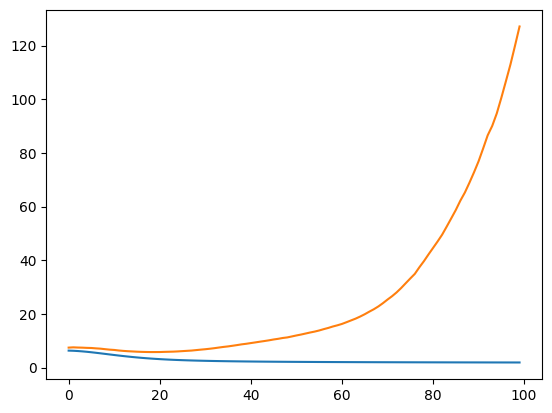

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fc545335640>

In [18]:
plot(tau)
plot(tau_allen)
#ylim(0, 20)

In [18]:
omegas = 0.01:0.01:1;
np.savetxt("tau_allen.txt", hcat(omegas, tau))

In [19]:
omegas, tau_allen = [col for col in eachcol(np.loadtxt("tau_allen.txt"))]

2-element Vector{SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}:
 [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1  …  0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0]
 [4.856421999014741, 7.706237575667105, 9.265914891211347, 9.950571380867343, 10.1339816074013, 10.101941028359228, 9.928293877935005, 9.582747869513412, 9.24788494351464, 8.923943758382611  …  84.15233944468187, 89.39495006056293, 95.05840294761698, 100.34096445643802, 106.78446008440451, 113.33923931342684, 119.20813504233463, 125.38602960975423, 132.79997410808136, 140.83950330418963]

In [19]:
color_allen = "#54BAB9"
color_taus = "#D75281"

figure(figsize=(3, 5))
title("τ ")
ylabel("Decay time (fs)")
xlabel("ħω (eV)")

loglog(omegas, taus, color=color_taus, linewidth=3, label="boltzmann")
loglog(omegas, tau_allen, color=color_allen, linewidth=3, label="Exact")
legend()

LoadError: UndefVarError: omegas not defined